# Notebook 1.1 — Price Explorer

**Learning objectives:**
- Read full-year regional dispatch price behaviour across the NEM
- Interpret price duration curves, intraday price shape, and negative-price timing
- Compare SA1 against other regions using spreads, correlations, and price-shape context
- Build intuition for why a few extreme intervals can dominate market outcomes

**Required data prep:**
```bash
uv run python import_nem_data.py --start 2025/01/01 --end 2025/12/31 --dispatchprice
uv run python import_nem_data.py --market-price-thresholds
uv run python build_market_price_reference.py
```

**Important import note:**
- `DISPATCHPRICE` is a normal time-series table, so the requested date window works as expected.
- `MARKET_PRICE_THRESHOLDS` is an effective-dated standing table in `nemosis`, so `--market-price-thresholds` walks historical monthly snapshots rather than respecting a narrow `--start/--end` window.
- That behaviour is expected for this table and is why the consolidation step exists.

**Data notes and quirks discovered during setup:**
- This notebook uses `DISPATCHPRICE` plus the consolidated reference file `../data/reference/market_price_thresholds.parquet`.
- It filters `DISPATCHPRICE` to `INTERVENTION = 0` so the charts reflect underlying dispatch prices rather than intervention-distorted intervals.
- `SETTLEMENTDATE` is shifted back by 5 minutes once at load time so the time index represents the interval start consistently across later analysis.
- For market-cap logic, use effective-dated `VOLL` from `MARKET_PRICE_THRESHOLDS`. In practice here, `VOLL` is the usable MPC reference.
- The old hardcoded `$15,000/MWh` threshold is wrong for 2025. The effective cap is `$17,500/MWh` until `2025-06-30 23:55`, then `$20,300/MWh` from `2025-07-01 00:00` onward.

Notebook 1.1 is the orientation pass: broad price shape first, deeper dispatch and constraint mechanics later.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from nemosis import dynamic_data_compiler
from mpl_toolkits.mplot3d import Axes3D
import os

CACHE = '../data/nemosis_cache'
REFERENCE = '../data/reference/market_price_thresholds.parquet'
REGION = 'VIC1'  # Global focus region for single-region analyses
os.makedirs(CACHE, exist_ok=True)

prices = dynamic_data_compiler(
    '2025/01/01 00:00:00',
    '2026/01/01 00:00:00',
    'DISPATCHPRICE', # 5-minute settlement prices for each NEM region.
    CACHE,
    fformat='parquet',
    filter_cols=['INTERVENTION'],
    filter_values=([0],) # INTERVENTION=0 keeps only non-intervention pricing
)[['SETTLEMENTDATE', 'REGIONID', 'RRP']]

# SETTLEMENTDATE is the *end* of the dispatch interval (e.g. 00:05 covers 00:00–00:05).
prices['SETTLEMENTDATE'] -= pd.Timedelta('5min')

# Pivot to wide format (rows = timestamps, columns = regions).
# This is the primary DataFrame used in all subsequent analysis.
prices_wide = (prices
    .pivot(index='SETTLEMENTDATE', columns='REGIONID', values='RRP')
    .sort_index()
)

# Market price thresholds are prepared outside the notebook from NEMOSIS monthly
# snapshots, then consolidated into one effective-dated reference file.
thresholds = pd.read_parquet(REFERENCE).copy()
thresholds['EFFECTIVEDATE'] = pd.to_datetime(thresholds['EFFECTIVEDATE'])
thresholds = (thresholds
    .sort_values(['EFFECTIVEDATE', 'VERSIONNO'])
    .drop_duplicates(['EFFECTIVEDATE', 'VERSIONNO'], keep='last')
)

# Assign the effective VOLL to each 5-minute interval via an as-of join.
interval_caps = pd.merge_asof(
    pd.DataFrame({'SETTLEMENTDATE': prices_wide.index}).sort_values('SETTLEMENTDATE'),
    thresholds[['EFFECTIVEDATE', 'VOLL']].sort_values('EFFECTIVEDATE'),
    left_on='SETTLEMENTDATE',
    right_on='EFFECTIVEDATE',
    direction='backward'
).set_index('SETTLEMENTDATE')['VOLL']
interval_caps.name = 'VOLL'

print()
print(prices_wide.head())
print(f"Shape: {prices_wide.shape}")
print(f"Memory: {prices_wide.memory_usage(deep=True).sum() / 1e6:.1f} MB")

# Use the effective VOLL for each interval rather than a hardcoded threshold.
print("\nEffective VOLL periods loaded from reference file:")
print(thresholds[['EFFECTIVEDATE', 'VOLL', 'MARKETPRICEFLOOR']].to_string(index=False))

print("\nHow many price cap intervals were there (RRP >= effective VOLL)?")
cap_events = prices_wide.ge(interval_caps, axis=0).sum()
print(cap_events)

# Negative prices occur when supply exceeds demand and generators bid negative
# to stay on-line (e.g. wind farms avoiding ramp costs, solar avoiding curtailment).
# SA and QLD typically lead on negative price count due to high renewable penetration.
print("\nHow many negative price intervals?")
neg_prices = (prices_wide < 0).sum()
print(neg_prices)
print(prices_wide.describe())



INFO: Compiling data for table DISPATCHPRICE


INFO: Returning DISPATCHPRICE.



REGIONID                  NSW1       QLD1        SA1       TAS1       VIC1
SETTLEMENTDATE                                                            
2025-01-01 00:00:00  138.02790  154.30294  141.47720  125.17761  130.00000
2025-01-01 00:05:00  134.41651  150.42180  136.58563  120.28000  125.50000
2025-01-01 00:10:00  135.89000  150.07326  142.05217  129.97176  129.02340
2025-01-01 00:15:00  120.30552  132.58249  129.64224  118.28000  116.96976
2025-01-01 00:20:00  119.88874  132.07553  129.51666  118.28000  116.49766
Shape: (105120, 5)
Memory: 5.0 MB

Effective VOLL periods loaded from reference file:
EFFECTIVEDATE  VOLL  MARKETPRICEFLOOR
   1997-11-04  5000             -1000
   2002-04-01 10000             -1000
   2010-07-01 12500             -1000
   2012-07-01 12900             -1000
   2013-07-01 13100             -1000
   2014-07-01 13500             -1000
   2015-07-01 13800             -1000
   2016-07-01 14000             -1000
   2017-07-01 14200             -1000
   2018-

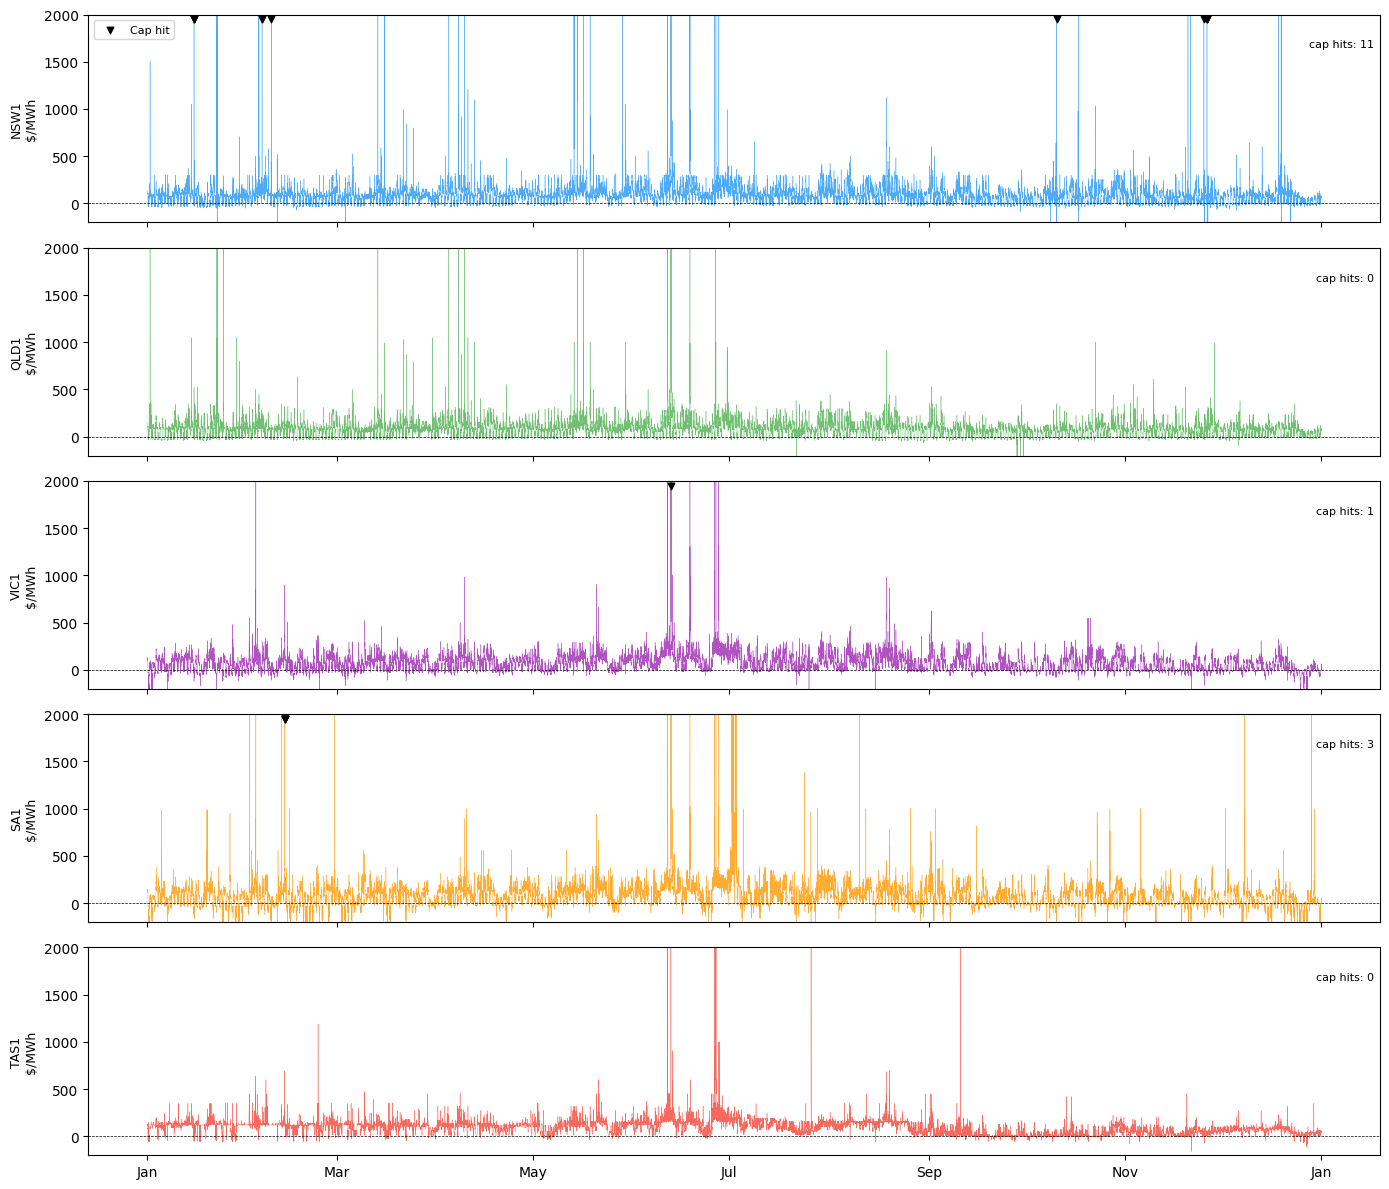

In [2]:
# Time Series Plot
# Full-year view of 5-minute prices for each region.
# Useful for spotting seasonal patterns, price spike clusters, and periods of
# sustained negative prices. Prices are capped at $2,000 for display — above
# this, the series becomes unreadable due to spike outliers.
# Cap-hit intervals (RRP >= effective VOLL, using INTERVENTION = 0 rows only)
# are marked with downward triangles at the top of each regional panel.
# The dashed zero line makes negative price periods immediately visible.

fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)
regions = ['NSW1', 'QLD1', 'VIC1', 'SA1', 'TAS1']
colors  = ['#2196F3', '#4CAF50', '#9C27B0', '#FF9800', '#F44336']

for ax, region, color in zip(axes, regions, colors):
    # Cap display at $2,000 for readability — spikes exist but collapse the y-axis.
    display = prices_wide[region].clip(upper=2000)
    cap_mask = prices_wide[region].ge(interval_caps)
    cap_times = prices_wide.index[cap_mask]
    cap_y = np.full(cap_mask.sum(), 1950.0)

    ax.plot(display.index, display, lw=0.3, color=color, alpha=0.8)
    if len(cap_times) > 0:
        ax.scatter(cap_times, cap_y, marker='v', s=22, color='black',
                   label='Cap hit' if region == regions[0] else None, zorder=4)
    ax.axhline(0, color='black', lw=0.5, ls='--')
    ax.set_ylabel(f'{region}\n$/MWh', fontsize=9)
    ax.set_ylim(-200, 2000)
    ax.text(0.995, 0.88, f'cap hits: {int(cap_mask.sum())}',
            transform=ax.transAxes, ha='right', va='top', fontsize=8,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2))

axes[0].legend(loc='upper left', frameon=True, fontsize=8)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.tight_layout()


Text(0.98, 0.02, 'Intervals > $500 clipped — NSW1: 443  QLD1: 222  VIC1: 363  SA1: 646  TAS1: 166')

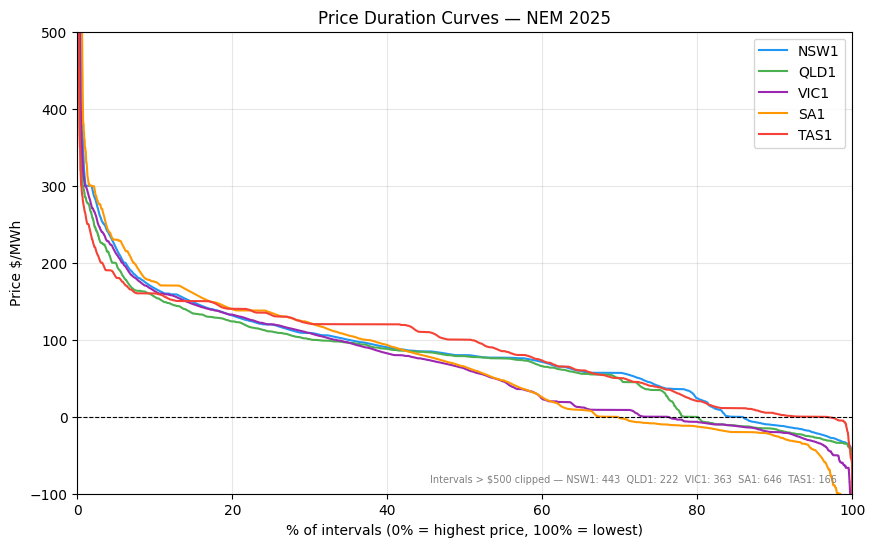

In [3]:
# Price Duration Curve (PDC)
# A PDC sorts all price observations from highest to lowest and plots them
# against the fraction of time that price was exceeded. Reading the chart:
#   - The left tail shows how severe and frequent price spikes are.
#   - Where the curve crosses $0 shows what fraction of time prices are negative.
#   - A steep left tail → volatile market with infrequent but large spikes (SA).
#   - A flat, low curve → stable, low-priced market (TAS, typically hydro-dominated).
# Y-axis is clipped at $500 to show the bulk of the distribution — spike counts
# are annotated so the clipped data isn't hidden.

fig, ax = plt.subplots(figsize=(10, 6))

for region, color in zip(regions, colors):
    sorted_prices = prices_wide[region].sort_values(ascending=False).values
    pct = (np.arange(len(sorted_prices)) / len(sorted_prices)) * 100  # x-axis: % of intervals
    ax.plot(pct, sorted_prices, label=region, color=color, lw=1.5)

ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_xlim(0, 100)
ax.set_ylim(-100, 500)   # zoom in on the bulk — spikes distort the top
ax.set_xlabel('% of intervals (0% = highest price, 100% = lowest)')
ax.set_ylabel('Price $/MWh')
ax.set_title('Price Duration Curves — NEM 2025')
ax.legend()
ax.grid(alpha=0.3)

# Show what's being clipped — the spikes are part of the story
clip_counts = {r: int((prices_wide[r] > 500).sum()) for r in regions}
clip_note = '  '.join(f'{r}: {n}' for r, n in clip_counts.items() if n > 0)
ax.text(0.98, 0.02, f'Intervals > $500 clipped — {clip_note}',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=7, color='gray')

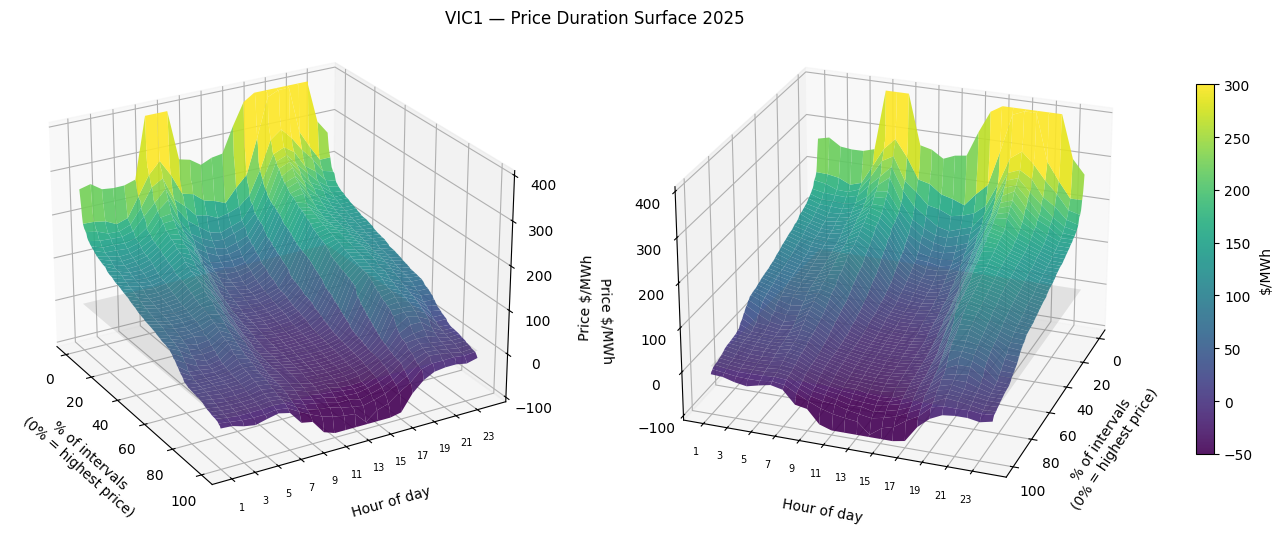

In [4]:
# 3D Price Duration Surface — by hour of day (REGION)
# Two synchronized viewpoints are shown side-by-side.
# Each horizontal slice through this surface is the PDC for a specific hour.
# Reading the surface:
#   - Y-axis (hour of day): look for how the shape changes between morning,
#     midday, and evening. Solar hours (10:00–15:00) should show a deep trough
#     in the centre of the surface (cheap/negative midday prices).
#   - X-axis (% of intervals): leftmost edge = highest prices, rightmost = lowest.
#   - Z-axis ($/MWh): height of the surface = price level at that percentile/hour.
#   - The grey zero plane makes it easy to see which hour/percentile combinations
#     produce negative prices (surface drops below the plane).
# Z is clipped at ±400 for visual clarity — extreme spike outliers would otherwise
# compress the rest of the surface into a flat floor.

region = REGION

# Prepare hourly price data
prices_hourly = prices_wide.resample('1h').mean()
df = prices_hourly[[region]].copy()
df['hour'] = df.index.hour + 1  # 1–24
df = df[df[region] > -500]      # drop extreme outliers for surface clarity

# Build percentile-by-hour matrix
percentiles = np.linspace(0, 100, 200)
hours = list(range(1, 25))
Z = np.zeros((len(hours), len(percentiles)))
for i, h in enumerate(hours):
    hour_prices = df[df['hour'] == h][region].dropna().values
    if len(hour_prices) > 0:
        Z[i, :] = np.percentile(hour_prices, 100 - percentiles)  # descending like PDC

X, Y = np.meshgrid(percentiles, hours)
Z_display = np.clip(Z, -100, 400)

# Plot two camera angles in one figure
fig = plt.figure(figsize=(18, 8))
angles = [(25, -30), (25, 20)]
mappable = None

for idx, (elev, azim) in enumerate(angles, start=1):
    ax = fig.add_subplot(1, 2, idx, projection='3d')
    surf = ax.plot_surface(
        X, Y, Z_display, cmap='viridis', vmin=-50, vmax=300, #'RdYlGn_r'
        alpha=0.9, linewidth=0, antialiased=True
    )
    mappable = surf
    xx, yy = np.meshgrid([0, 100], [1, 24])  # zero plane
    ax.plot_surface(xx, yy, np.zeros_like(xx), alpha=0.15, color='grey')
    ax.set_xlabel('% of intervals\n(0% = highest price)', labelpad=10)
    ax.set_ylabel('Hour of day', labelpad=10)
    ax.set_zlabel('Price $/MWh', labelpad=10)
    ax.set_yticks(range(1, 25, 2))
    ax.set_yticklabels(range(1, 25, 2), fontsize=7)
    ax.view_init(elev=elev, azim=azim)

fig.suptitle(f'{region} — Price Duration Surface 2025', y=0.82, x=0.45)
fig.colorbar(mappable, ax=fig.axes, label='$/MWh', shrink=0.6, pad=0.03)
plt.show()




/tmp/ipykernel_72141/1274800606.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.02, 1, 0.92])
/tmp/ipykernel_72141/1274800606.py:85: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0.02, 1, 0.92])


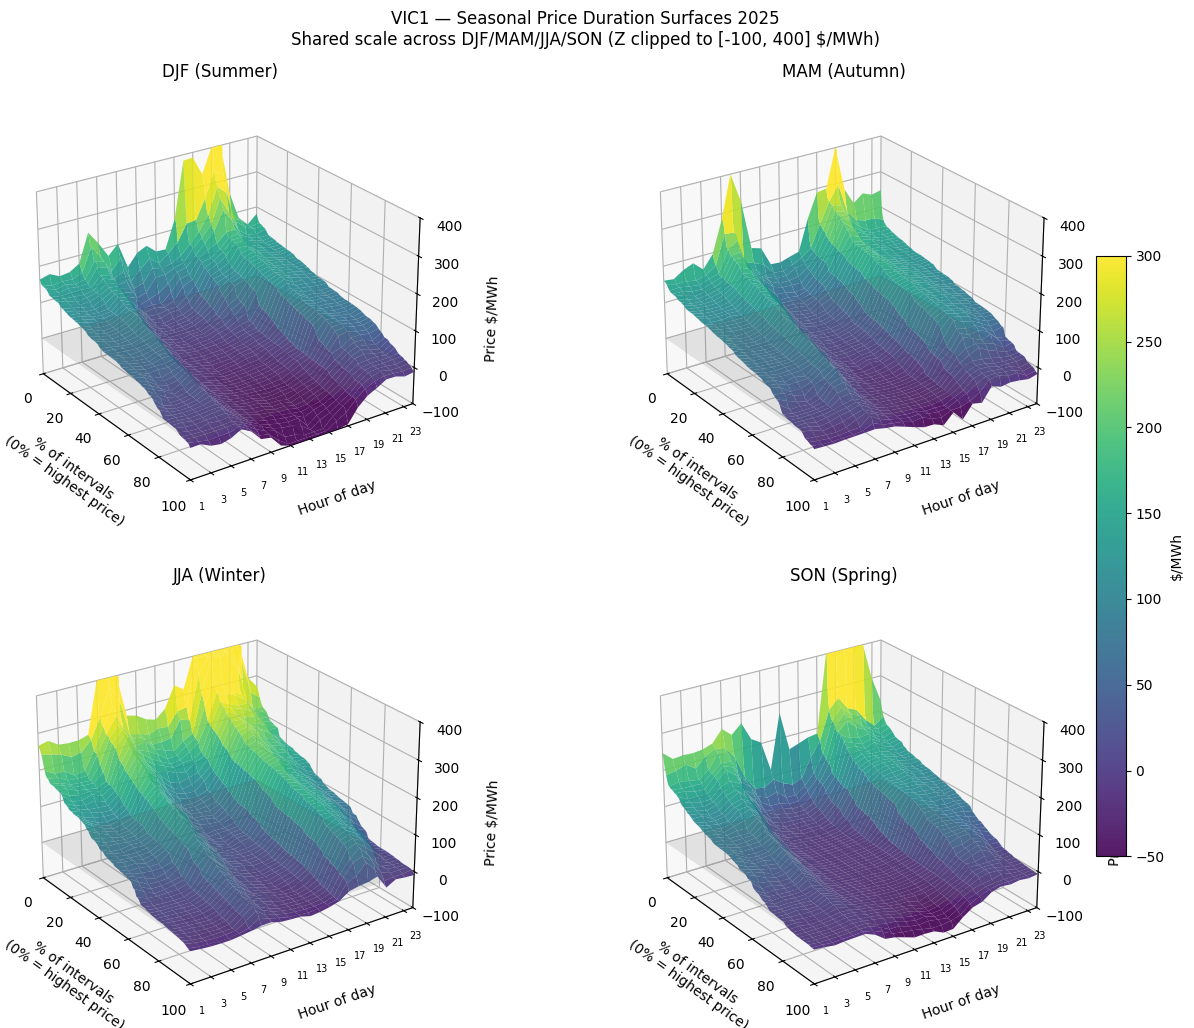

Interpretation notes:
  Left-tail spike intensity highest: JJA (Winter)
  Deepest midday trough (P50, 10:00–15:00): DJF (Summer)
  Steepest evening premium (18:00–21:00 vs 10:00–15:00): JJA (Winter)


In [5]:
# Seasonal PDC Surface — REGION (meteorological seasons)
# This extends the all-year 3D surface by splitting data into DJF/MAM/JJA/SON.
# Each panel is a full percentile duration surface by hour of day for one season.
# Keep this as a secondary shape/intution plot; use ribbon + heatmap as primary evidence.

region = REGION

# Prepare hourly price data
df = prices_wide.resample('1h').mean()[[region]].copy()
df['hour'] = df.index.hour + 1  # 1–24
df['month'] = df.index.month
df = df[df[region] > -500]      # drop extreme outliers for surface clarity

# Meteorological seasons
season_map = {
    12: 'DJF', 1: 'DJF', 2: 'DJF',
    3: 'MAM', 4: 'MAM', 5: 'MAM',
    6: 'JJA', 7: 'JJA', 8: 'JJA',
    9: 'SON', 10: 'SON', 11: 'SON'
}
df['season'] = df['month'].map(season_map)

season_order = ['DJF', 'MAM', 'JJA', 'SON']
season_labels = {
    'DJF': 'DJF (Summer)',
    'MAM': 'MAM (Autumn)',
    'JJA': 'JJA (Winter)',
    'SON': 'SON (Spring)'
}

# Build percentile-by-hour matrix for each season
percentiles = np.linspace(0, 100, 200)
hours = list(range(1, 25))
X, Y = np.meshgrid(percentiles, hours)

surfaces = {}
for season in season_order:
    Z = np.zeros((len(hours), len(percentiles)))
    sdf = df[df['season'] == season]
    for i, h in enumerate(hours):
        hour_prices = sdf[sdf['hour'] == h][region].dropna().values
        if len(hour_prices) > 0:
            Z[i, :] = np.percentile(hour_prices, 100 - percentiles)  # descending like PDC
    surfaces[season] = Z

# Shared clipping and color scale across all 4 panels
CLIP_LO, CLIP_HI = -100, 400
VMIN, VMAX = -50, 300

# Plot 2x2 seasonal surfaces
fig = plt.figure(figsize=(18, 12))
mappable = None

for idx, season in enumerate(season_order, start=1):
    ax = fig.add_subplot(2, 2, idx, projection='3d')
    Z_display = np.clip(surfaces[season], CLIP_LO, CLIP_HI)

    surf = ax.plot_surface(
        X, Y, Z_display, cmap='viridis', vmin=VMIN, vmax=VMAX,
        alpha=0.9, linewidth=0, antialiased=True
    )
    mappable = surf

    xx, yy = np.meshgrid([0, 100], [1, 24])  # zero plane
    ax.plot_surface(xx, yy, np.zeros_like(xx), alpha=0.15, color='grey')

    ax.set_xlim(0, 100)
    ax.set_ylim(1, 24)
    ax.set_zlim(CLIP_LO, CLIP_HI)

    ax.set_xlabel('% of intervals\n(0% = highest price)', labelpad=10)
    ax.set_ylabel('Hour of day', labelpad=10)
    ax.set_zlabel('Price $/MWh', labelpad=10)
    ax.set_yticks(range(1, 25, 2))
    ax.set_yticklabels(range(1, 25, 2), fontsize=7)
    ax.view_init(elev=25, azim=-35)
    ax.set_title(season_labels[season], pad=12)

fig.suptitle(
    f'{region} — Seasonal Price Duration Surfaces 2025\n'
    'Shared scale across DJF/MAM/JJA/SON (Z clipped to [-100, 400] $/MWh)',
    y=0.95
)
fig.colorbar(mappable, ax=fig.axes, label='$/MWh', shrink=0.65, pad=0.03)
plt.tight_layout(rect=[0, 0.02, 1, 0.92])
plt.show()

# Short interpretation block
p50_idx = np.argmin(np.abs(percentiles - 50))

left_tail_peak = {}
midday_p50 = {}
evening_p50 = {}
evening_premium = {}

for season in season_order:
    Z = surfaces[season]
    left_tail_peak[season] = np.max(Z[:, 0])
    midday_p50[season] = np.mean(Z[9:15, p50_idx])      # 10:00–15:00
    evening_p50[season] = np.mean(Z[17:21, p50_idx])    # 18:00–21:00
    evening_premium[season] = evening_p50[season] - midday_p50[season]

season_spike = max(left_tail_peak, key=left_tail_peak.get)
season_midday_low = min(midday_p50, key=midday_p50.get)
season_ramp = max(evening_premium, key=evening_premium.get)

print('Interpretation notes:')
print(f"  Left-tail spike intensity highest: {season_labels[season_spike]}")
print(f"  Deepest midday trough (P50, 10:00–15:00): {season_labels[season_midday_low]}")
print(f"  Steepest evening premium (18:00–21:00 vs 10:00–15:00): {season_labels[season_ramp]}")




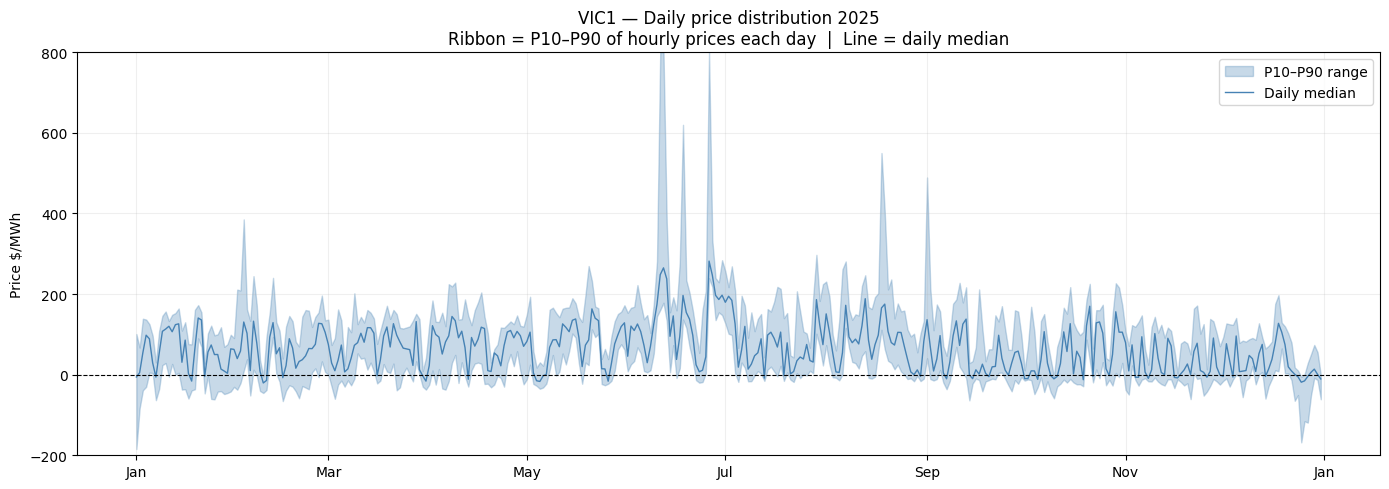

Days with negative median price:       47
Days with P10–P90 spread > $200/MWh:  31  (high intra-day volatility)


In [6]:
# Daily price distribution ribbon — REGION
# The ribbon spans P10–P90 (80% of hours each day); the line is the daily median.
#
# Reading the chart:
#   - Narrow ribbon = low intra-day spread (stable generation mix that day)
#   - Wide ribbon   = large cheap-midday / expensive-peak spread (solar duck curve days)
#   - Ribbon dipping below $0 = negative prices occurred that day
#   - Seasonal clusters of wide ribbons → typically summer demand peaks and spring solar surplus

region = REGION

# Filter to one region before resampling — avoids resampling 4 unused columns
daily = (prices_wide[region]
         .resample('1h').mean()
         .resample('D').quantile([0.1, 0.5, 0.9])
         .unstack())
daily.columns = ['p10', 'median', 'p90']

CLIP_LO, CLIP_HI = -200, 800
daily_plot = daily.clip(CLIP_LO, CLIP_HI)  # clip once, reuse in all three plot calls

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(daily_plot.index, daily_plot['p10'], daily_plot['p90'],
                alpha=0.3, color='steelblue', label='P10–P90 range')
ax.plot(daily_plot.index, daily_plot['median'],
        color='steelblue', lw=1.0, label='Daily median')
ax.axhline(0, color='black', lw=0.8, ls='--')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.set_ylabel('Price $/MWh')
ax.set_title(f'{region} — Daily price distribution 2025\n'
             f'Ribbon = P10–P90 of hourly prices each day  |  Line = daily median')
ax.legend(loc='upper right')
ax.set_ylim(CLIP_LO, CLIP_HI)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

n_neg_median = (daily['median'] < 0).sum()
n_wide = (daily['p90'] - daily['p10'] > 200).sum()
print(f"Days with negative median price:       {n_neg_median}")
print(f"Days with P10–P90 spread > $200/MWh:  {n_wide}  (high intra-day volatility)")


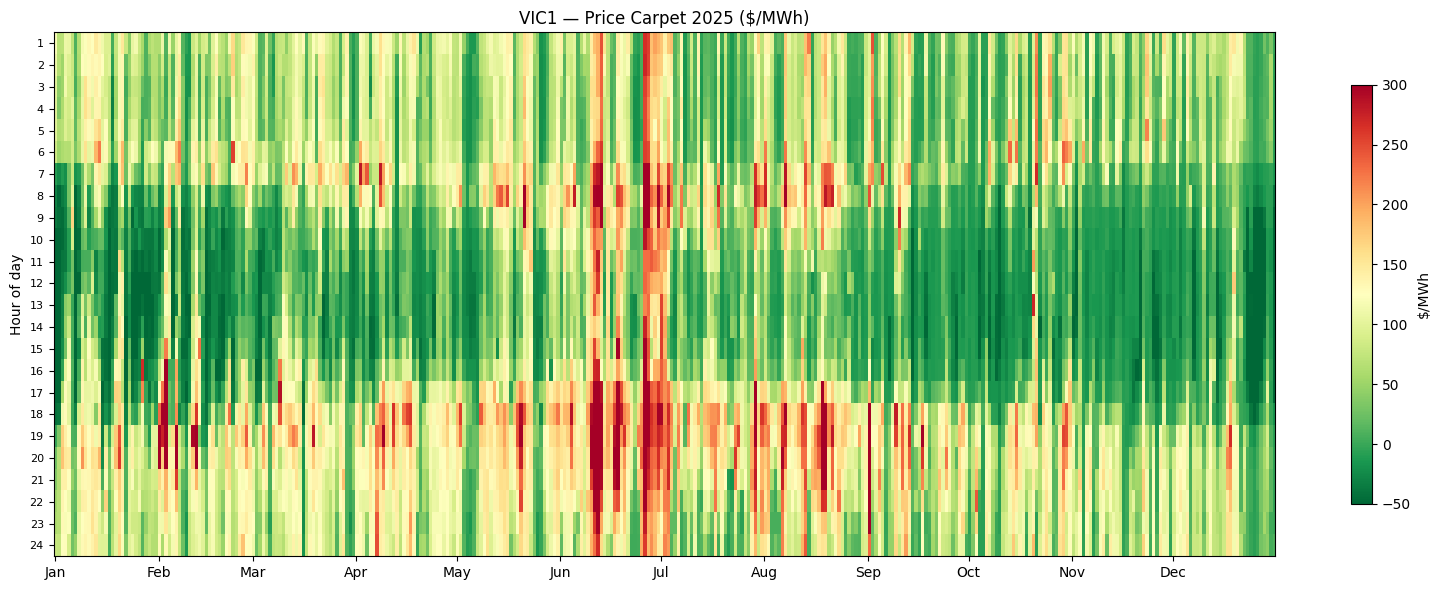

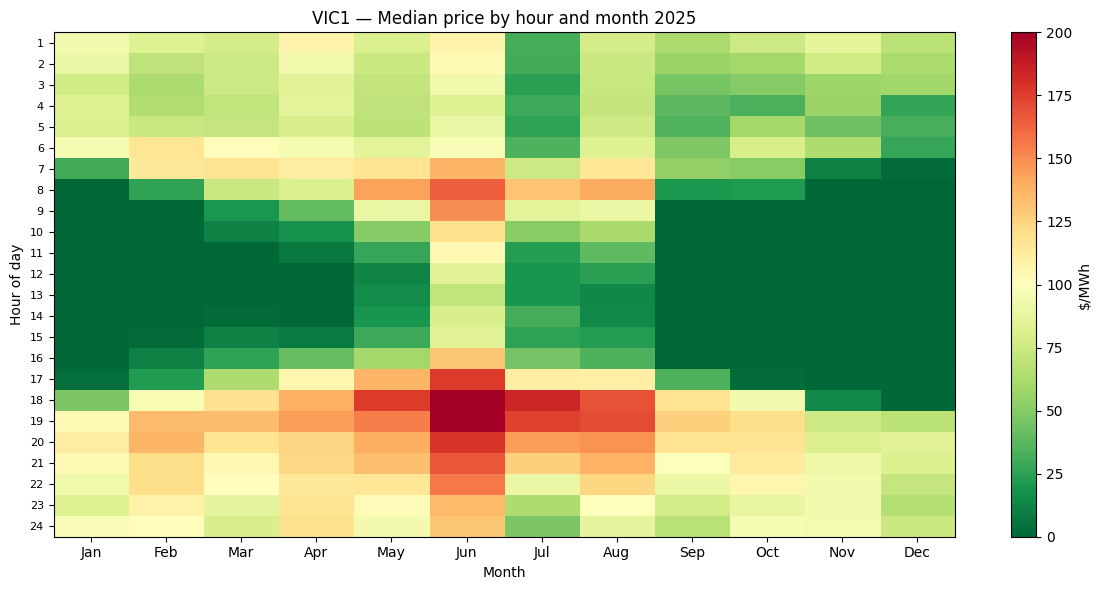

In [7]:
# Price Carpet — REGION
# A carpet plot maps the full year on the x-axis and hours of the day on the y-axis.
# Each cell is coloured by the mean price in that hour on that calendar day.
# This is a dense, information-rich view that makes several patterns visible at once:
#   - Vertical bands of colour → multi-day price events (heatwaves, generator outages).
#   - Horizontal colour gradients → intra-day price shape (cheap midday, expensive morning/evening).
#   - Seasonal colour shift → summer/winter demand differences.
#   - Green patches in midday rows (hours 10–15) → solar surplus driving prices negative.
# Colour scale is clipped at $300 — spike outliers would wash out the gradient otherwise.

# Median Price Heatmap — by hour of day and month
# Shows the typical intra-day price shape for each month of the year.
# Using median (not mean) to reduce the influence of spike events.
# Reading the chart:
#   - Dark red cells = expensive hours (morning/evening demand peaks).
#   - Green/yellow cells = cheap or negative hours (midday solar, overnight low demand).
#   - Compare months: summer months should show higher afternoon prices in SA/NSW
#     (air conditioning load) while spring/autumn show deeper midday troughs (solar surplus).
# Plotted for SA1, VIC1, and NSW1 to contrast renewable-heavy and gas-peaking markets.

region = REGION
prices_hourly = prices_wide.resample('1h').mean()

# --- Plot 1: price carpet (day-of-year x hour) ---
df = prices_hourly[[region]].copy()
df['hour'] = df.index.hour + 1        # 1–24
df['day_of_year'] = df.index.dayofyear

# Pivot: rows = hour of day, columns = calendar day
pivot = df.pivot_table(
    values=region,
    index='hour',           # y-axis: 1–24
    columns='day_of_year',  # x-axis: 1–365
    aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(16, 6))
im = ax.imshow(
    pivot,
    aspect='auto',
    cmap='RdYlGn_r',
    vmin=-50, vmax=300,     # clip — don't let spikes dominate colour scale
    interpolation='nearest'
)

# X-axis: label by month
month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']
ax.set_xticks([d - 1 for d in month_starts])  # -1 because imshow is 0-indexed
ax.set_xticklabels(month_labels)

ax.set_yticks(range(24))
ax.set_yticklabels(range(1, 25), fontsize=8)
ax.set_ylabel('Hour of day')
ax.set_title(f'{region} — Price Carpet 2025 ($/MWh)')

plt.colorbar(im, label='$/MWh', shrink=0.8)
plt.tight_layout()
plt.show()

# --- Plot 2: median heatmap (month x hour) ---
df = prices_hourly[[region]].copy()

# Hour bucket 1–24 (not 0–23)
df['hour'] = df.index.hour + 1      # shifts 0-23 → 1-24
df['month'] = df.index.month

pivot = df.pivot_table(
    values=region,
    index='hour',       # 1–24, 24 rows
    columns='month',
    aggfunc='median'
)

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(pivot, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=200)

ax.set_xlabel('Month')
ax.set_ylabel('Hour of day')
ax.set_yticks(range(24))
ax.set_yticklabels(range(1, 25), fontsize=8)
ax.set_title(f'{region} — Median price by hour and month 2025')
ax.set_xticks(range(12))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.colorbar(im, label='$/MWh')
plt.tight_layout()
plt.show()



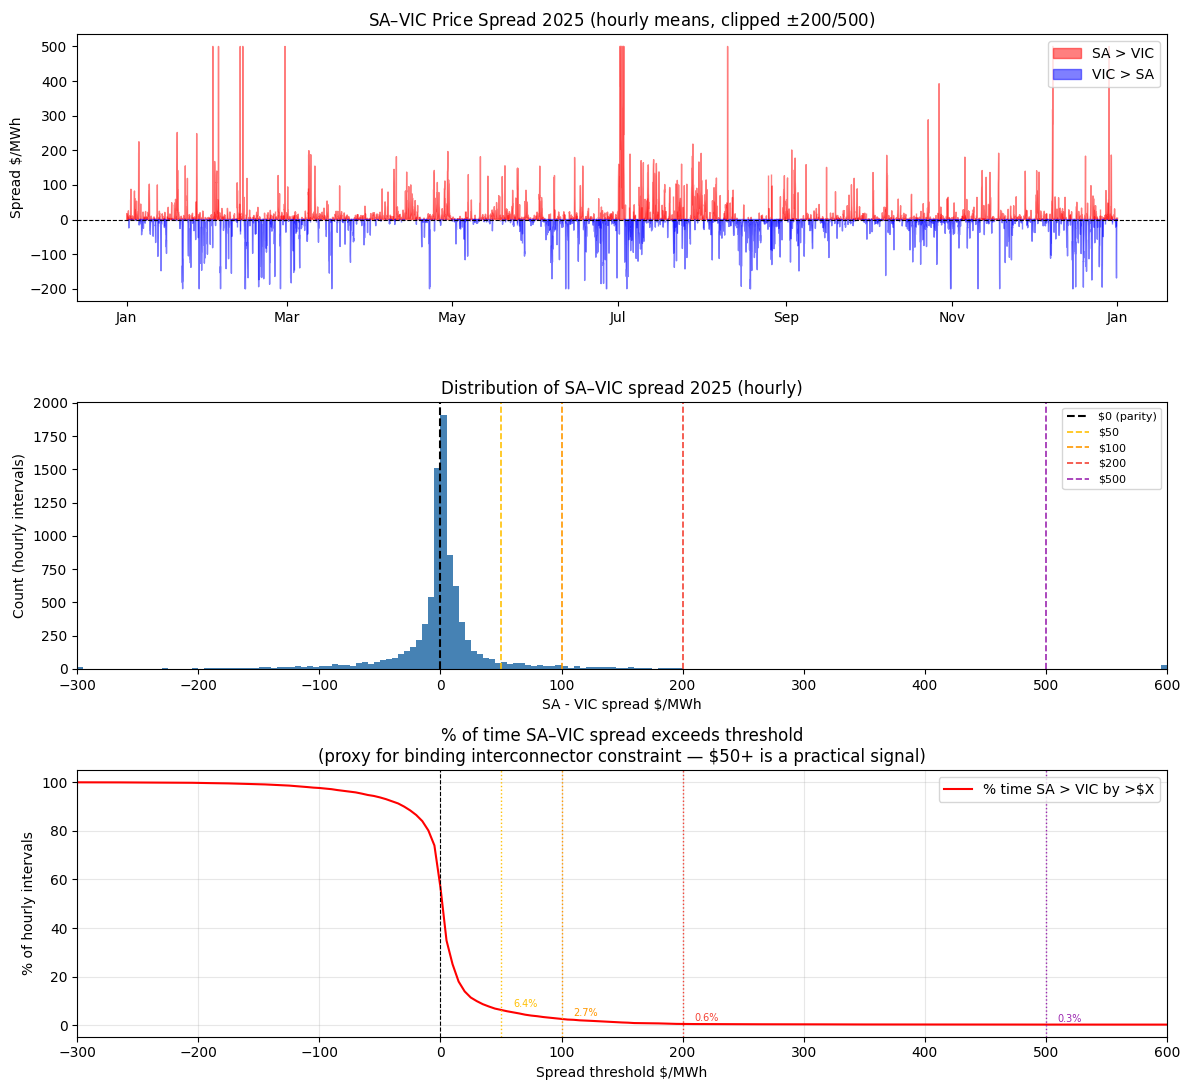

SA–VIC spread summary (hourly intervals)

  Mean spread:         8.8 $/MWh
  Median spread:       0.8 $/MWh
  Std dev:           206.8 $/MWh

  Interconnector constraint proxy (SA > VIC by threshold):
    > $   0:  56.7% of intervals  ( 4967 intervals,  4967 hrs)
    > $  10:  25.1% of intervals  ( 2202 intervals,  2202 hrs)
    > $  50:   6.4% of intervals  (  559 intervals,   559 hrs)
    > $ 100:   2.7% of intervals  (  233 intervals,   233 hrs)
    > $ 200:   0.6% of intervals  (   52 intervals,    52 hrs)
    > $ 500:   0.3% of intervals  (   30 intervals,    30 hrs)

  VIC > SA (negative spread, SA exporting or oversupplied):
    > $  10:  19.9% of intervals  ( 1741 intervals,  1741 hrs)
    > $  50:   6.3% of intervals  (  553 intervals,   553 hrs)
    > $ 100:   2.4% of intervals  (  214 intervals,   214 hrs)
    > $ 200:   0.4% of intervals  (   32 intervals,    32 hrs)


In [8]:
# SA–VIC Price Spread
# The spread (SA price minus VIC price) is a proxy for the interconnector margin.
# When SA is more expensive than VIC (positive spread), it suggests:
#   - The Heywood interconnector is importing at capacity (SA is short of supply), or
#   - SA has a local price event (generator trip, high gas prices).
# When VIC is more expensive (negative spread):
#   - SA is exporting, or
#   - SA has excess renewable generation pushing prices down.
#
# Interconnectors have a small unavoidable loss component, so a spread of ~$0–$10
# can exist even with an unconstrained interconnector. Spreads persistently above
# ~$50–$100 are a more reliable proxy for binding interconnector constraints.

spread = prices_wide['SA1'] - prices_wide['VIC1']
spread_hourly = spread.resample('1h').mean()
spread_display = spread_hourly.clip(-200, 500)

fig, axes = plt.subplots(3, 1, figsize=(12, 11))

# --- Top: spread time series (hourly) ---
axes[0].fill_between(spread_display.index, spread_display, 0,
                     where=spread_display > 0, alpha=0.5, color='red',  label='SA > VIC')
axes[0].fill_between(spread_display.index, spread_display, 0,
                     where=spread_display < 0, alpha=0.5, color='blue', label='VIC > SA')
axes[0].axhline(0, color='black', lw=0.8, ls='--')
axes[0].set_title('SA–VIC Price Spread 2025 (hourly means, clipped ±$200/$500)')
axes[0].set_ylabel('Spread $/MWh')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
axes[0].legend(loc='upper right')

# --- Shared x-range for panels 2 and 3 so x=0 aligns visually ---
XMIN, XMAX = -300, 600

# --- Middle: distribution (hourly) with log y-scale ---
thresholds = [50, 100, 200, 500]
threshold_colors = ['#FFC107', '#FF9800', '#F44336', '#9C27B0']

axes[1].hist(spread_hourly.clip(XMIN, XMAX), bins=180, color='steelblue', edgecolor='none')
axes[1].axvline(0, color='black', lw=1.5, ls='--', label='$0 (parity)')
for t, c in zip(thresholds, threshold_colors):
    axes[1].axvline(t, color=c, lw=1.2, ls='--', label=f'${t}')
axes[1].set_xlim(XMIN, XMAX)
axes[1].set_xlabel('SA - VIC spread $/MWh')
axes[1].set_title('Distribution of SA–VIC spread 2025 (hourly)')
axes[1].set_ylabel('Count (hourly intervals)')
axes[1].legend(loc='upper right', fontsize=8)

# --- Bottom: exceedance curve with finer threshold grid (hourly) ---
threshold_range = np.arange(XMIN, XMAX + 1, 5)
threshold_arr = threshold_range[:, None]
pct_above = (spread_hourly.values > threshold_arr).mean(axis=1) * 100
t_idx = {t: i for i, t in enumerate(threshold_range)}

axes[2].plot(threshold_range, pct_above, color='red', lw=1.5, label='% time SA > VIC by >$X')
axes[2].axvline(0, color='black', lw=0.8, ls='--')
for t, c in zip(thresholds, threshold_colors):
    pct = pct_above[t_idx[t]]
    axes[2].axvline(t, color=c, lw=1, ls=':')
    axes[2].annotate(f'{pct:.1f}%', xy=(t, pct), xytext=(t + 10, pct + 1.2),
                     fontsize=7, color=c)
axes[2].set_xlim(XMIN, XMAX)
axes[2].set_xlabel('Spread threshold $/MWh')
axes[2].set_ylabel('% of hourly intervals')
axes[2].set_title('% of time SA–VIC spread exceeds threshold\n'
                  '(proxy for binding interconnector constraint — $50+ is a practical signal)')
axes[2].legend(loc='upper right')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# --- Summary table (hourly intervals) ---
print('SA–VIC spread summary (hourly intervals)\n')
print(f'  Mean spread:    {spread_hourly.mean():>8.1f} $/MWh')
print(f'  Median spread:  {spread_hourly.median():>8.1f} $/MWh')
print(f'  Std dev:        {spread_hourly.std():>8.1f} $/MWh')
print()

pos_t = np.array([0, 10, 50, 100, 200, 500])
pos_mask = spread_hourly.values > pos_t[:, None]
pos_n, pos_pct = pos_mask.sum(axis=1), pos_mask.mean(axis=1) * 100

print('  Interconnector constraint proxy (SA > VIC by threshold):')
for t, n, pct in zip(pos_t, pos_n, pos_pct):
    print(f'    > ${t:>4}: {pct:5.1f}% of intervals  ({n:>5} intervals, {n:>5} hrs)')

neg_t = np.array([10, 50, 100, 200])
neg_mask = spread_hourly.values < -neg_t[:, None]
neg_n, neg_pct = neg_mask.sum(axis=1), neg_mask.mean(axis=1) * 100

print()
print('  VIC > SA (negative spread, SA exporting or oversupplied):')
for t, n, pct in zip(neg_t, neg_n, neg_pct):
    print(f'    > ${t:>4}: {pct:5.1f}% of intervals  ({n:>5} intervals, {n:>5} hrs)')



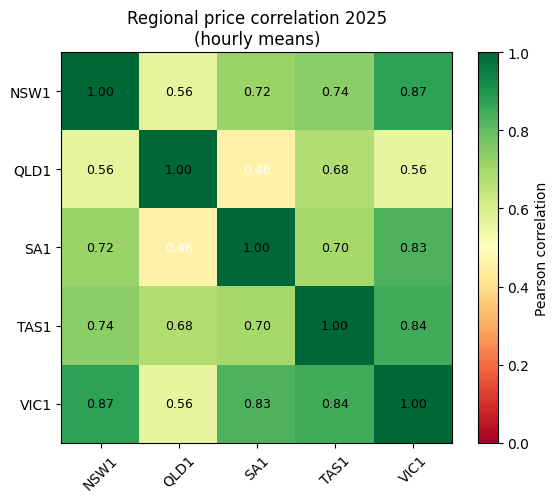

REGIONID      NSW1      QLD1       SA1      TAS1      VIC1
REGIONID                                                  
NSW1      1.000000  0.562724  0.717862  0.738923  0.872458
QLD1      0.562724  1.000000  0.459735  0.677576  0.560762
SA1       0.717862  0.459735  1.000000  0.697510  0.831557
TAS1      0.738923  0.677576  0.697510  1.000000  0.844879
VIC1      0.872458  0.560762  0.831557  0.844879  1.000000


In [ ]:
# Regional price correlation
# How tightly coupled are the five NEM regions?
# Values near 1 = regions move together (interconnected, similar fuel mix)
# Values near 0 = regions decouple (Basslink constrained for TAS, or SA islanding)
corr = prices_wide.resample('1h').mean().corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xticks(range(5))
ax.set_xticklabels(corr.columns, rotation=45)
ax.set_yticks(range(5))
ax.set_yticklabels(corr.index)

# Annotate each cell with the correlation value
for i in range(5):
    for j in range(5):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}',
  qwwq              ha='center', va='center', fontsize=9,
                color='black' if corr.iloc[i, j] > 0.5 else 'white')

plt.colorbar(im, label='Pearson correlation')
ax.set_title('Regional price correlation 2025\n(hourly means)')
plt.tight_layout()
plt.show()

print(corr.to_string())

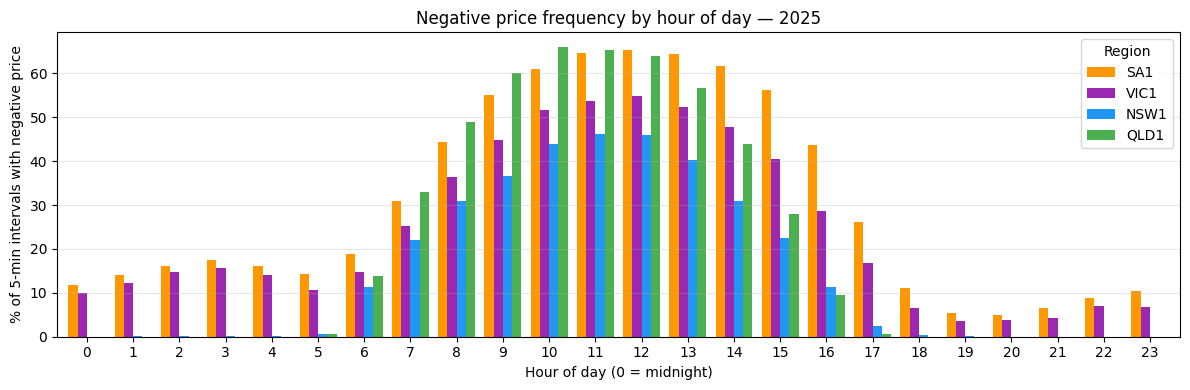


Peak negative price hour by region:
  SA1: hour 12:00 — 65.4% of intervals
  VIC1: hour 12:00 — 54.8% of intervals
  NSW1: hour 11:00 — 46.1% of intervals
  QLD1: hour 10:00 — 66.1% of intervals


In [10]:
# Negative price frequency by hour of day
# Negative prices occur when there is excess generation that cannot be curtailed
# (e.g. must-run wind/solar during low-demand periods). Generators bid negative
# to avoid being dispatched off and losing production tax credits or RPO compliance.
# High negative price frequency in midday hours → solar-driven curtailment pressure.
# SA and VIC should show a pronounced midday trough; QLD may differ due to solar mix.
neg_by_hour = (prices_wide < 0).groupby(prices_wide.index.hour).mean() * 100

fig, ax = plt.subplots(figsize=(12, 4))
neg_by_hour[['SA1', 'VIC1', 'NSW1', 'QLD1']].plot(
    kind='bar', ax=ax,
    color=['#FF9800', '#9C27B0', '#2196F3', '#4CAF50'],
    width=0.8
)
ax.set_xlabel('Hour of day (0 = midnight)')
ax.set_ylabel('% of 5-min intervals with negative price')
ax.set_title('Negative price frequency by hour of day — 2025')
ax.legend(title='Region')
ax.grid(axis='y', alpha=0.3)
ax.set_xticklabels(range(24), rotation=0)
plt.tight_layout()
plt.show()

print("\nPeak negative price hour by region:")
for region in ['SA1', 'VIC1', 'NSW1', 'QLD1']:
    peak_hour = neg_by_hour[region].idxmax()
    peak_pct = neg_by_hour[region].max()
    print(f"  {region}: hour {peak_hour:02d}:00 — {peak_pct:.1f}% of intervals")

nb local edit proof

This cell was appended locally by `nb` after disconnecting from the Jupyter server.